```
fruletov/
├── clips/         -- нарезанные 10-секундные wav-файлы
├── features.pkl   -- {sample_id: {audio_path, source_id, ...}}
├── targets.pkl    -- {sample_id: {class_id}}
├── train_keys.pkl -- {idx: {key: sample_id}, ...}
├── val_keys.pkl   -- {idx: {key: sample_id}, ...}
├── test_keys.pkl  -- {idx: {key: sample_id}, ...}
├── manifest.csv   -- метаданные по каждому чанку
└── metadata.json  -- сводка по датасету
```

In [6]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import soundfile as sf

repo_root = Path('.').resolve().parent
if str(repo_root) not in sys.path:
    sys.path.append(str(repo_root))

from src.data.preprocessing.fruletov import (
    DEFAULT_FRULETOV_LABELS,
    FruletovPreprocessingConfig,
    iter_fruletov_source_paths,
    preprocess_fruletov_dataset,
)

## Настройка

In [7]:
raw_dir = repo_root / 'data' / 'raw' / 'Fruletov'
raw_dataset_dir = raw_dir / 'Dataset Nov 2021'
preprocessed_dir = repo_root / 'data' / 'preprocessed' / 'fruletov'

chunk_duration_seconds = 10.0
stride_seconds = 10.0
target_sample_rate = 16000
split_gap_seconds = 10.0
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

print(f'Raw dir: {raw_dir}')
print(f'Raw dataset dir: {raw_dataset_dir}')
print(f'Preprocessed dir: {preprocessed_dir}')

Raw dir: /Users/shocolatka/Learn/autodition/data/raw/Fruletov
Raw dataset dir: /Users/shocolatka/Learn/autodition/data/raw/Fruletov/Dataset Nov 2021
Preprocessed dir: /Users/shocolatka/Learn/autodition/data/preprocessed/fruletov


## Загрузка

In [8]:
download_url = 'https://drive.google.com/drive/folders/11gBa3XlAIdDyq4p3n2hnFBP6uskMtm-_?usp=drive_link'
raw_dir.mkdir(parents=True, exist_ok=True)

print(f'Download Fruletov dataset from: {download_url}')
print(f'Target directory: {raw_dir}')
print(f'gdown --folder "{download_url}" -O "{raw_dir}"')

Download Fruletov dataset from: https://drive.google.com/drive/folders/11gBa3XlAIdDyq4p3n2hnFBP6uskMtm-_?usp=drive_link
Target directory: /Users/shocolatka/Learn/autodition/data/raw/Fruletov
gdown --folder "https://drive.google.com/drive/folders/11gBa3XlAIdDyq4p3n2hnFBP6uskMtm-_?usp=drive_link" -O "/Users/shocolatka/Learn/autodition/data/raw/Fruletov"


## Обзор

In [10]:
source_rows = []
for source_path in iter_fruletov_source_paths(raw_dataset_dir):
    info = sf.info(source_path)
    source_rows.append(
        {
            'source_file': source_path.name,
            'source_id': source_path.stem,
            'duration_seconds': info.duration,
            'sample_rate': info.samplerate,
            'channels': info.channels,
            'frames': info.frames,
        }
    )

source_metadata = pd.DataFrame(source_rows).sort_values('source_file').reset_index(drop=True)
display(source_metadata)

,source_file,source_id,duration_seconds,sample_rate,channels,frames
0,Car Horn Full.wav,Car Horn Full,570.476961,44100,2,25158034
1,Car Idling Full.wav,Car Idling Full,631.698277,44100,2,27857894
2,Car acceleration Full.wav,Car acceleration Full,450.572222,44100,2,19870235
3,Car braking Full.wav,Car braking Full,571.029683,44100,2,25182409
4,Moto Acceleration Full.wav,Moto Acceleration Full,1477.255542,48000,2,70908266
5,Moto Idling Full.wav,Moto Idling Full,913.443311,44100,2,40282850
6,Siren 1 Full.wav,Siren 1 Full,1458.919796,44100,2,64338363
7,Siren 4 Full.wav,Siren 4 Full,1455.039478,44100,2,64167241
8,Siren 5 Full.wav,Siren 5 Full,1414.151633,44100,2,62364087
9,Tram Acceleration Full.wav,Tram Acceleration Full,782.359646,48000,2,37553263


## Сборка

In [11]:
config = FruletovPreprocessingConfig(
    raw_dataset_dir=raw_dataset_dir,
    preprocessed_dir=preprocessed_dir,
    chunk_duration_seconds=chunk_duration_seconds,
    stride_seconds=stride_seconds,
    target_sample_rate=target_sample_rate,
    split_gap_seconds=split_gap_seconds,
    train_ratio=train_ratio,
    val_ratio=val_ratio,
    test_ratio=test_ratio,
)

summary = preprocess_fruletov_dataset(config)
pd.Series(summary, name='value').to_frame()

,value
num_samples,1542
train_samples,1078
val_samples,228
test_samples,236


In [12]:
manifest = pd.read_csv(preprocessed_dir / 'manifest.csv')
metadata = json.loads((preprocessed_dir / 'metadata.json').read_text(encoding='utf-8'))

print('Manifest shape:', manifest.shape)
display(manifest.head())
display(pd.DataFrame(metadata['split_counts'].items(), columns=['split', 'num_samples']))

Manifest shape: (1542, 15)


,sample_id,split,class_name,class_id,source_id,source_audio_path,clip_audio_path,chunk_index,start_frame,end_frame,start_seconds,end_seconds,duration_seconds,source_sample_rate,target_sample_rate
0,car_acceleration_full__chunk_00000,train,car_acceleration,0,car_acceleration_full,Car acceleration Full.wav,clips/car_acceleration_full__chunk_00000.wav,0,0,441000,0.0,10.0,10.0,44100,16000
1,car_acceleration_full__chunk_00001,train,car_acceleration,0,car_acceleration_full,Car acceleration Full.wav,clips/car_acceleration_full__chunk_00001.wav,1,441000,882000,10.0,20.0,10.0,44100,16000
2,car_acceleration_full__chunk_00002,train,car_acceleration,0,car_acceleration_full,Car acceleration Full.wav,clips/car_acceleration_full__chunk_00002.wav,2,882000,1323000,20.0,30.0,10.0,44100,16000
3,car_acceleration_full__chunk_00003,train,car_acceleration,0,car_acceleration_full,Car acceleration Full.wav,clips/car_acceleration_full__chunk_00003.wav,3,1323000,1764000,30.0,40.0,10.0,44100,16000
4,car_acceleration_full__chunk_00004,train,car_acceleration,0,car_acceleration_full,Car acceleration Full.wav,clips/car_acceleration_full__chunk_00004.wav,4,1764000,2205000,40.0,50.0,10.0,44100,16000


,split,num_samples
0,train,1078
1,val,228
2,test,236


## Разведочный анализ данных

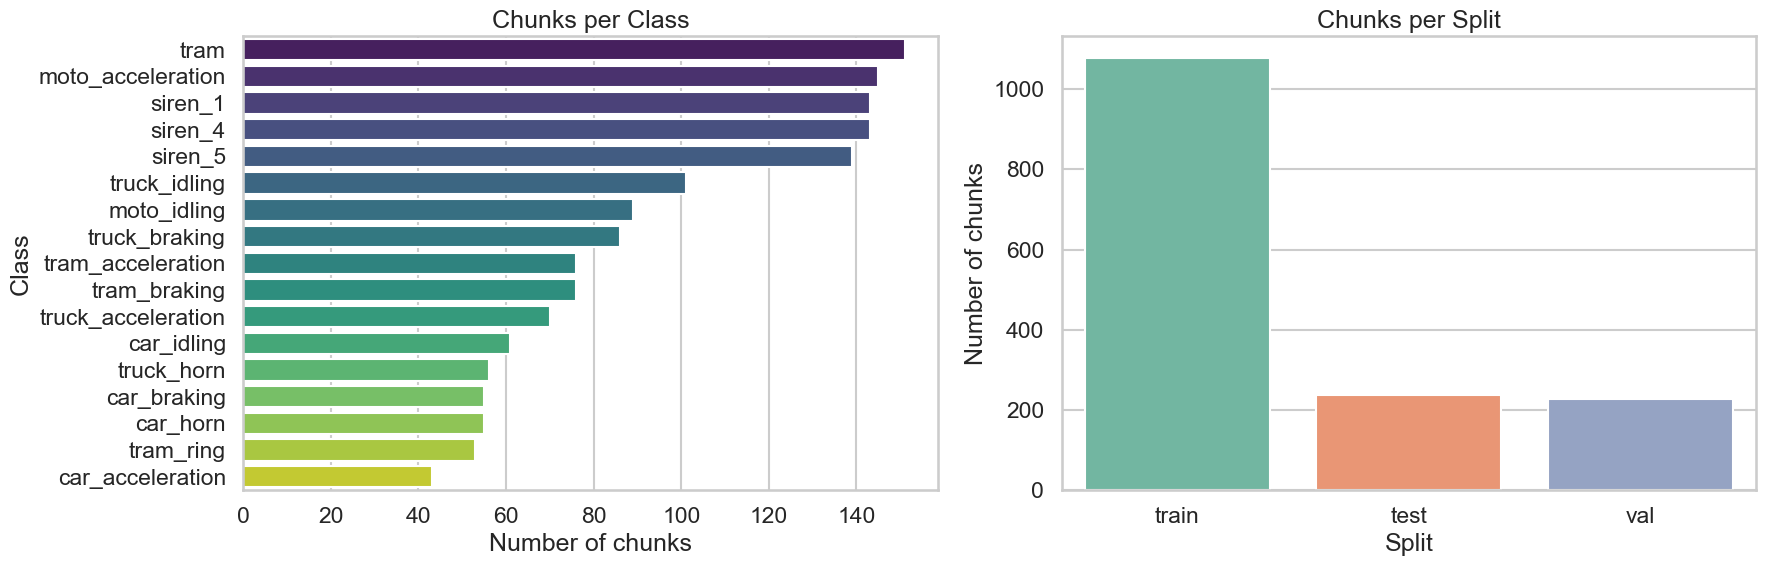

In [14]:
sns.set_theme(style='whitegrid', context='talk')

class_counts = manifest['class_name'].value_counts().rename_axis('class_name').reset_index(name='num_samples')
split_counts = manifest['split'].value_counts().rename_axis('split').reset_index(name='num_samples')

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(data=class_counts, x='num_samples', y='class_name', hue='class_name', palette='viridis', ax=axes[0], legend=False)
axes[0].set_title('Chunks per Class')
axes[0].set_xlabel('Number of chunks')
axes[0].set_ylabel('Class')

sns.barplot(data=split_counts, x='split', y='num_samples', hue='split', palette='Set2', ax=axes[1], legend=False)
axes[1].set_title('Chunks per Split')
axes[1].set_xlabel('Split')
axes[1].set_ylabel('Number of chunks')

plt.tight_layout()
plt.show()

### Замечания о балансе

После разбиения на чанки датасет не сбалансирован по классам. Записи с сиренами, трамваями и мотоциклами дают заметно больше обучающих примеров, чем некоторые категории событий для легковых и грузовых автомобилей.

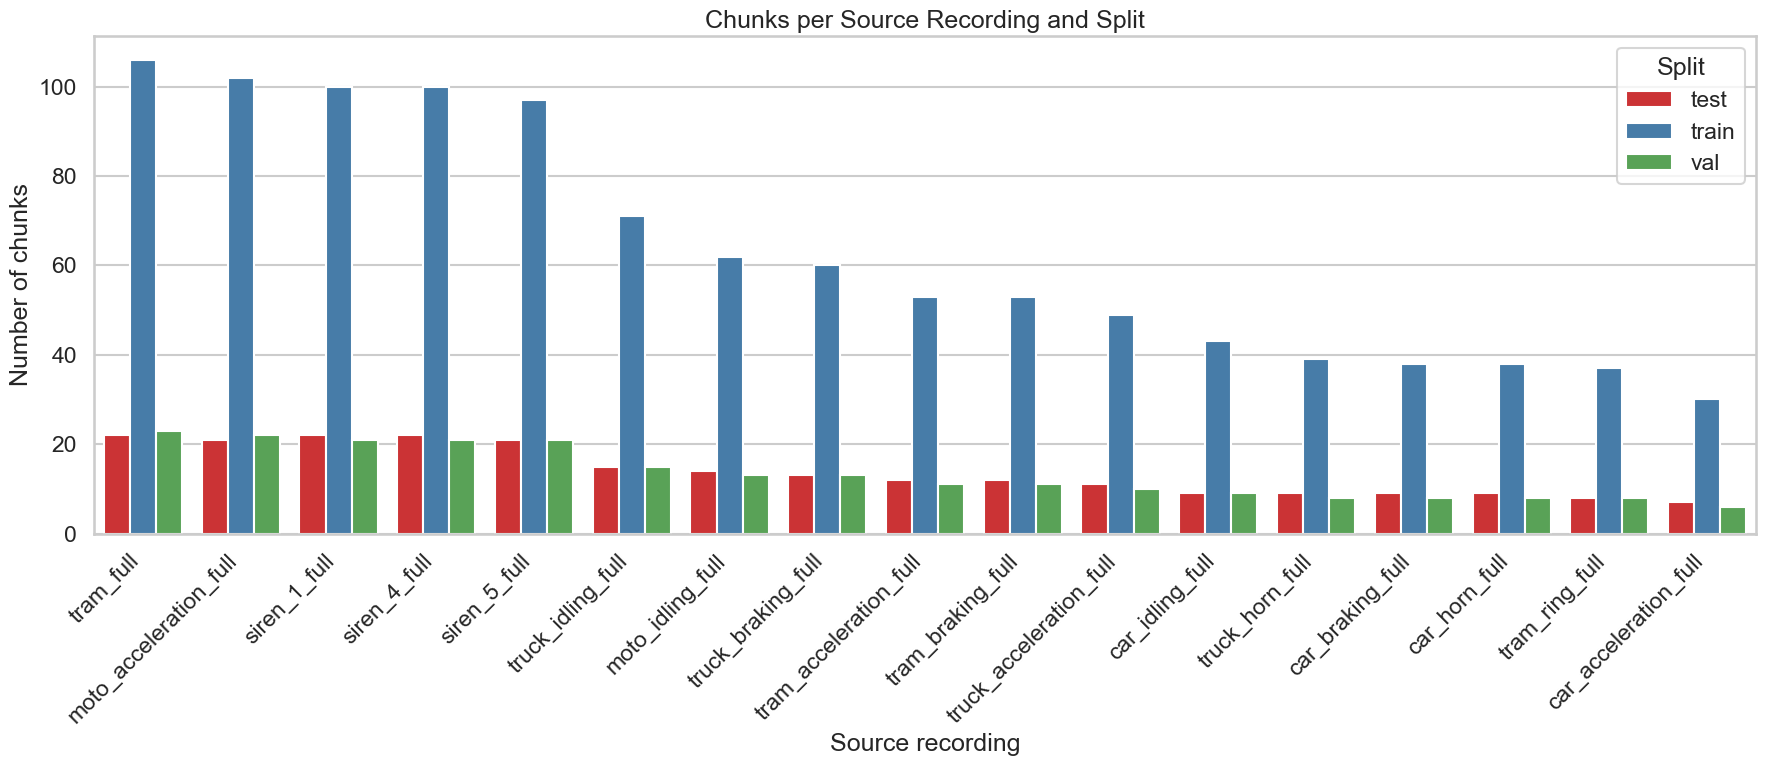

In [15]:
source_chunk_counts = manifest.groupby(['source_id', 'split']).size().rename('num_chunks').reset_index()
source_order = manifest.groupby('source_id').size().sort_values(ascending=False).index

plt.figure(figsize=(18, 8))
sns.barplot(data=source_chunk_counts, x='source_id', y='num_chunks', hue='split', order=source_order, palette='Set1')
plt.title('Chunks per Source Recording and Split')
plt.xlabel('Source recording')
plt.ylabel('Number of chunks')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Split')
plt.tight_layout()
plt.show()

### Замечания об источниках

Каждый класс представлен очень небольшим числом длинных исходных записей, а выборки обучения, валидации и теста формируются как непрерывные блоки внутри этих записей. Поэтому независимость разбиений ограничена разнообразием источников, а не только количеством чанков.

,split,mean,median,std
0,test,10.0,10.0,0.0
1,train,10.0,10.0,0.0
2,val,10.0,10.0,0.0


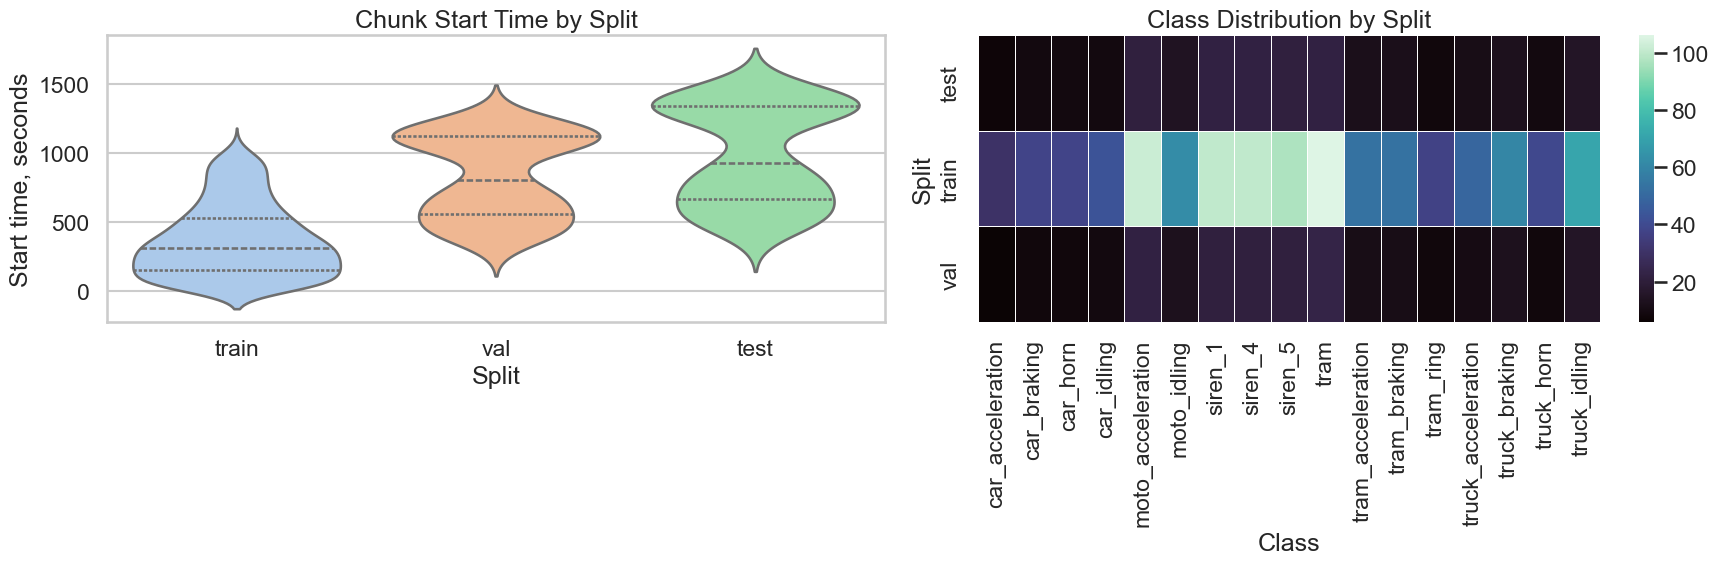

In [17]:
split_class_counts = manifest.groupby(["split", "class_name"]).size().unstack(fill_value=0)
split_duration = manifest.groupby("split")["duration_seconds"].agg(["mean", "median", "std"]).reset_index()
display(split_duration)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.violinplot(
    data=manifest,
    x="split",
    y="start_seconds",
    hue="split",
    palette="pastel",
    inner="quartile",
    ax=axes[0],
    legend=False
)
axes[0].set_title("Chunk Start Time by Split")
axes[0].set_xlabel("Split")
axes[0].set_ylabel("Start time, seconds")

sns.heatmap(split_class_counts, cmap="mako", linewidths=0.5, ax=axes[1])
axes[1].set_title("Class Distribution by Split")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Split")

plt.tight_layout()
plt.show()

### Замечания о покрытии

Датасет ориентирован на сценарии городского транспорта в движении, но покрытие по семействам событий неравномерно. Набор меток детальнее, чем у UrbanSound8K, однако для ряда классов по-прежнему опирается одна длинная запись, что сужает оценки устойчивости моделей.

,split,mean,median,std
0,test,10.0,10.0,0.0
1,train,10.0,10.0,0.0
2,val,10.0,10.0,0.0


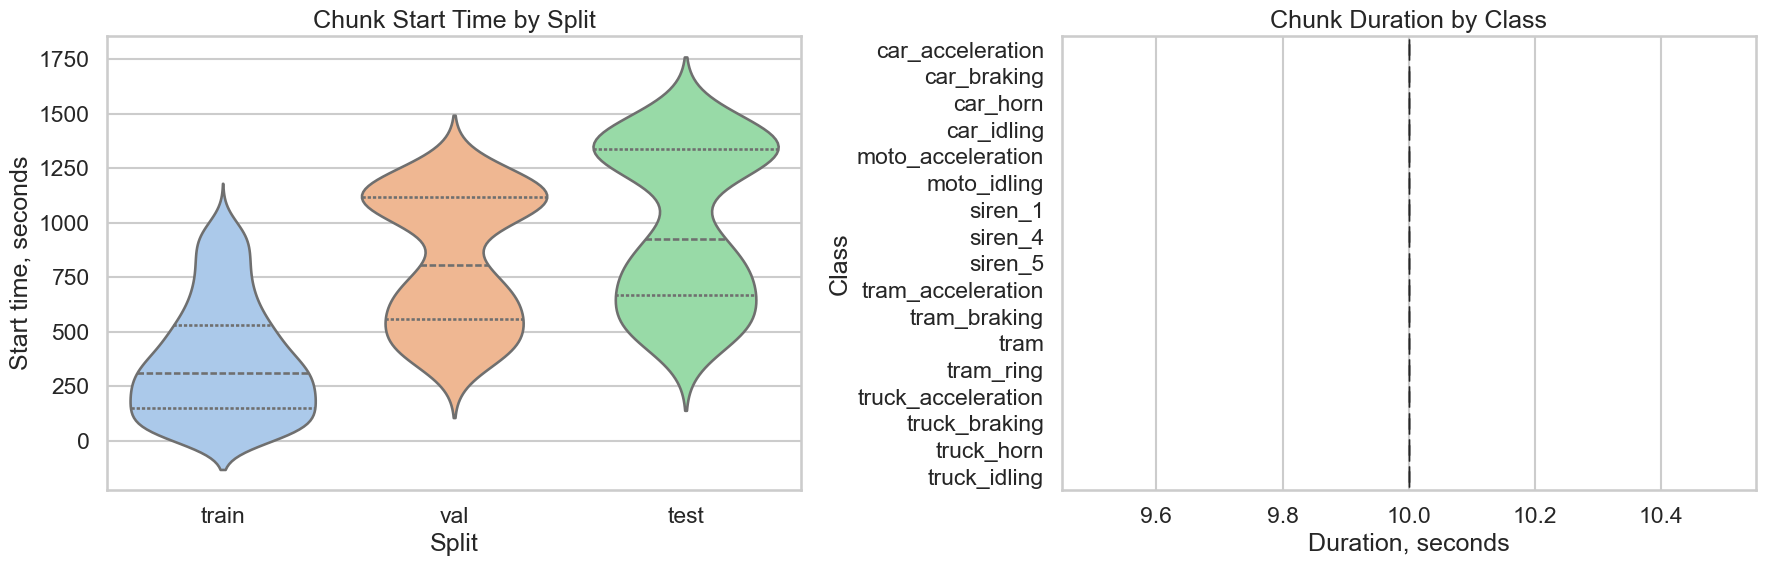

In [19]:
split_timeline = manifest.groupby(['split', 'class_name'])[['start_seconds', 'end_seconds']].agg(['min', 'max']).reset_index()
split_timeline.columns = ['split', 'class_name', 'start_min', 'start_max', 'end_min', 'end_max']

split_duration = manifest.groupby('split')['duration_seconds'].agg(['mean', 'median', 'std']).reset_index()
display(split_duration)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.violinplot(
    data=manifest,
    x='split',
    y='start_seconds',
    hue='split',
    palette='pastel',
    inner='quartile',
    ax=axes[0],
    legend=False
)
axes[0].set_title('Chunk Start Time by Split')
axes[0].set_xlabel('Split')
axes[0].set_ylabel('Start time, seconds')

sns.boxplot(
    data=manifest,
    x='duration_seconds',
    y='class_name',
    hue='class_name',
    palette='viridis',
    ax=axes[1],
    legend=False
)
axes[1].set_title('Chunk Duration by Class')
axes[1].set_xlabel('Duration, seconds')
axes[1].set_ylabel('Class')

plt.tight_layout()
plt.show()

### Итоги по датасету

Furletov полезен как предметно-ориентированный бенчмарк транспортного аудио с более узкими классами, чем у UrbanSound8K.

Главное ограничение — низкое разнообразие источников: многие чанки происходят из небольшого числа длинных записей, поэтому метрики оценки следует интерпретировать скорее как обобщение внутри источников, а не как широкое покрытие реального мира.

Фиксированная нарезка по 10 секунд стабилизирует препроцессинг, но при отчёте о метриках на последующих этапах стоит учитывать дисбаланс классов и зависимость от источников.